# Week 7: Classification — Logistic Regression, Naive Bayes, KNN

**Goal:** Apply the first three classifiers to the SER task.  For each, compare your MiniLearn implementation against scikit-learn and report all required metrics.

**Deliverable:** `minilearn/classifiers.py` (LR, NB, KNN complete) + this notebook.

---
## Checklist
- [ ] `LogisticRegression` — softmax, gradient descent, multi-class
- [ ] `GaussianNaiveBayes` — Gaussian likelihood, log-probabilities
- [ ] `KNearestNeighbors` — Euclidean distance, majority vote
- [ ] All minilearn.metrics implemented (accuracy, precision, recall, F1, confusion matrix)
- [ ] MiniLearn vs sklearn comparison table
- [ ] Per-class analysis: which emotions are confused?

In [11]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.classifiers import LogisticRegression, GaussianNaiveBayes, KNearestNeighbors
from minilearn.metrics import accuracy, precision, recall, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Load Preprocessed Features

Load the standardized feature arrays saved at the end of Week 5.

In [12]:
# Load the standardized arrays saved at the end of Week 5
X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Classes : {np.unique(y_train)}')
print(f'Train class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}')


def plot_confusion(cm, title, ax, labels):
    """Heatmap helper used in every section."""
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

X_train : (1956, 112)
X_test  : (496, 112)
Classes : [1 2 3 4 5 6 7 8]
Train class counts: {np.int64(1): np.int64(150), np.int64(2): np.int64(300), np.int64(3): np.int64(300), np.int64(4): np.int64(300), np.int64(5): np.int64(300), np.int64(6): np.int64(300), np.int64(7): np.int64(153), np.int64(8): np.int64(153)}


## 2. Logistic Regression

=== MiniLearn LogisticRegression ===
Accuracy : 0.6452
Macro F1 : 0.6402
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral             0.6216     0.6053     0.6133         38
calm                0.6889     0.8158     0.7470         76
happy               0.6486     0.6316     0.6400         76
sad                 0.5362     0.4868     0.5103         76
angry               0.7397     0.7105     0.7248         76
fearful             0.6615     0.5658     0.6099         76
disgust             0.6444     0.7436     0.6905         39
surprised           0.5581     0.6154     0.5854         39
-----------------------------------------------------------
weighted avg        0.6440     0.6452     0.6425        496

=== sklearn LogisticRegression ===
Accuracy : 0.6734
Macro F1 : 0.6693
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral        

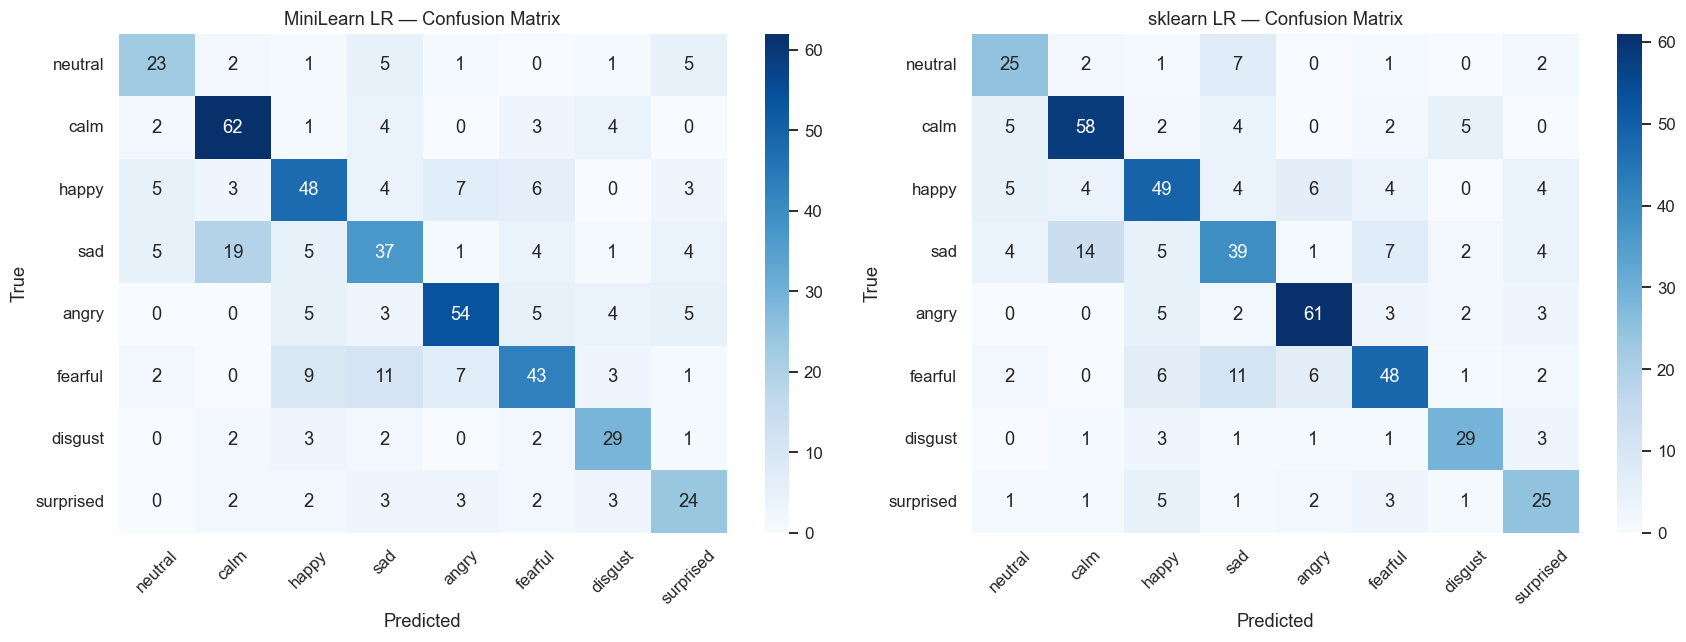

In [13]:
# ── MiniLearn Logistic Regression ───────────────────────────────────────────
ml_lr = LogisticRegression(lr=0.1, n_iter=500, tol=1e-5)
ml_lr.fit(X_train, y_train)
y_pred_ml_lr = ml_lr.predict(X_test)

print('=== MiniLearn LogisticRegression ===')
print(f'Accuracy : {accuracy(y_test, y_pred_ml_lr):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_ml_lr, average="macro"):.4f}')
classification_report(y_test, y_pred_ml_lr, class_names=emotion_labels)

# ── sklearn Logistic Regression ──────────────────────────────────────────────
sk_lr = SklearnLR(max_iter=1000, solver='lbfgs')
sk_lr.fit(X_train, y_train)
y_pred_sk_lr = sk_lr.predict(X_test)

print('\n=== sklearn LogisticRegression ===')
print(f'Accuracy : {accuracy(y_test, y_pred_sk_lr):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_sk_lr, average="macro"):.4f}')
classification_report(y_test, y_pred_sk_lr, class_names=emotion_labels)

# ── Confusion matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion(confusion_matrix(y_test, y_pred_ml_lr),
               'MiniLearn LR — Confusion Matrix', axes[0], emotion_labels)
plot_confusion(confusion_matrix(y_test, y_pred_sk_lr),
               'sklearn LR — Confusion Matrix',   axes[1], emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_logistic_regression.png'), bbox_inches='tight')
plt.show()

## 3. Gaussian Naive Bayes

=== MiniLearn GaussianNaiveBayes ===
Accuracy : 0.3750
Macro F1 : 0.3490
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral             0.2963     0.2105     0.2462         38
calm                0.5211     0.4868     0.5034         76
happy               0.3000     0.4737     0.3673         76
sad                 0.4500     0.1184     0.1875         76
angry               0.6104     0.6184     0.6144         76
fearful             0.3810     0.2105     0.2712         76
disgust             0.2097     0.3333     0.2574         39
surprised           0.2597     0.5128     0.3448         39
-----------------------------------------------------------
weighted avg        0.4063     0.3750     0.3641        496

=== sklearn GaussianNB ===
Accuracy : 0.3750
Macro F1 : 0.3490
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral             0.2

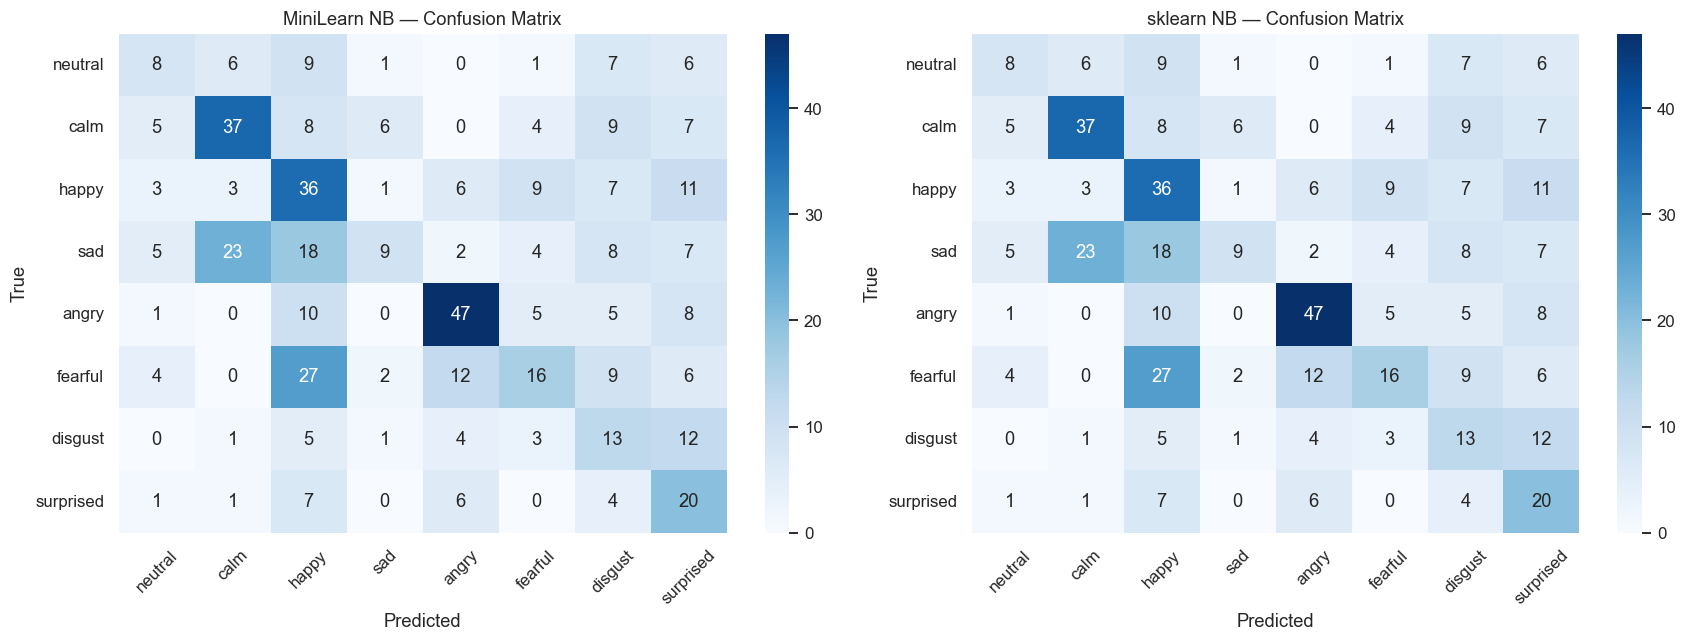

In [14]:
# ── MiniLearn Gaussian Naive Bayes ──────────────────────────────────────────
ml_nb = GaussianNaiveBayes()
ml_nb.fit(X_train, y_train)
y_pred_ml_nb = ml_nb.predict(X_test)

print('=== MiniLearn GaussianNaiveBayes ===')
print(f'Accuracy : {accuracy(y_test, y_pred_ml_nb):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_ml_nb, average="macro"):.4f}')
classification_report(y_test, y_pred_ml_nb, class_names=emotion_labels)

# ── sklearn GaussianNB ───────────────────────────────────────────────────────
sk_nb = GaussianNB()
sk_nb.fit(X_train, y_train)
y_pred_sk_nb = sk_nb.predict(X_test)

print('\n=== sklearn GaussianNB ===')
print(f'Accuracy : {accuracy(y_test, y_pred_sk_nb):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_sk_nb, average="macro"):.4f}')
classification_report(y_test, y_pred_sk_nb, class_names=emotion_labels)

# ── Confusion matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion(confusion_matrix(y_test, y_pred_ml_nb),
               'MiniLearn NB — Confusion Matrix', axes[0], emotion_labels)
plot_confusion(confusion_matrix(y_test, y_pred_sk_nb),
               'sklearn NB — Confusion Matrix',   axes[1], emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_naive_bayes.png'), bbox_inches='tight')
plt.show()

## 4. k-Nearest Neighbors

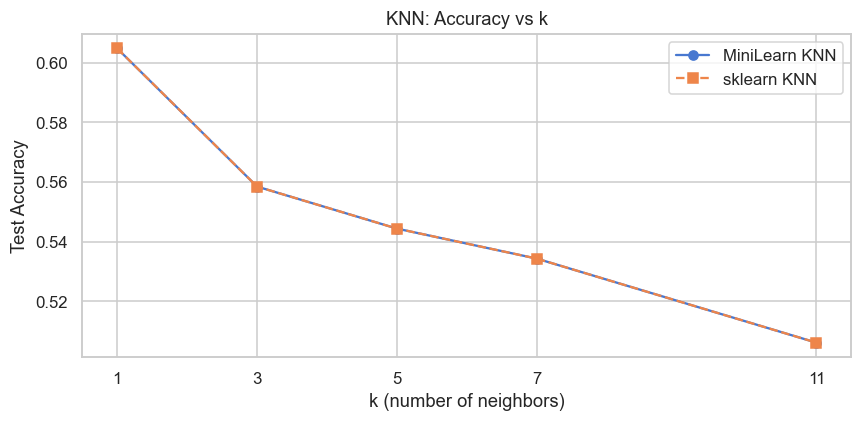

Best k (MiniLearn): 1

=== MiniLearn KNN (k=1) ===
Accuracy : 0.6048
Macro F1 : 0.5841
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral             0.4444     0.4211     0.4324         38
calm                0.6628     0.7500     0.7037         76
happy               0.5581     0.6316     0.5926         76
sad                 0.5082     0.4079     0.4526         76
angry               0.7500     0.7895     0.7692         76
fearful             0.6250     0.5921     0.6081         76
disgust             0.6538     0.4359     0.5231         39
surprised           0.5306     0.6667     0.5909         39
-----------------------------------------------------------
weighted avg        0.6028     0.6048     0.5997        496

=== sklearn KNN (k=1) ===
Accuracy : 0.6048
Macro F1 : 0.5841
Class            Precision     Recall         F1    Support
-----------------------------------------------------------
neutral   

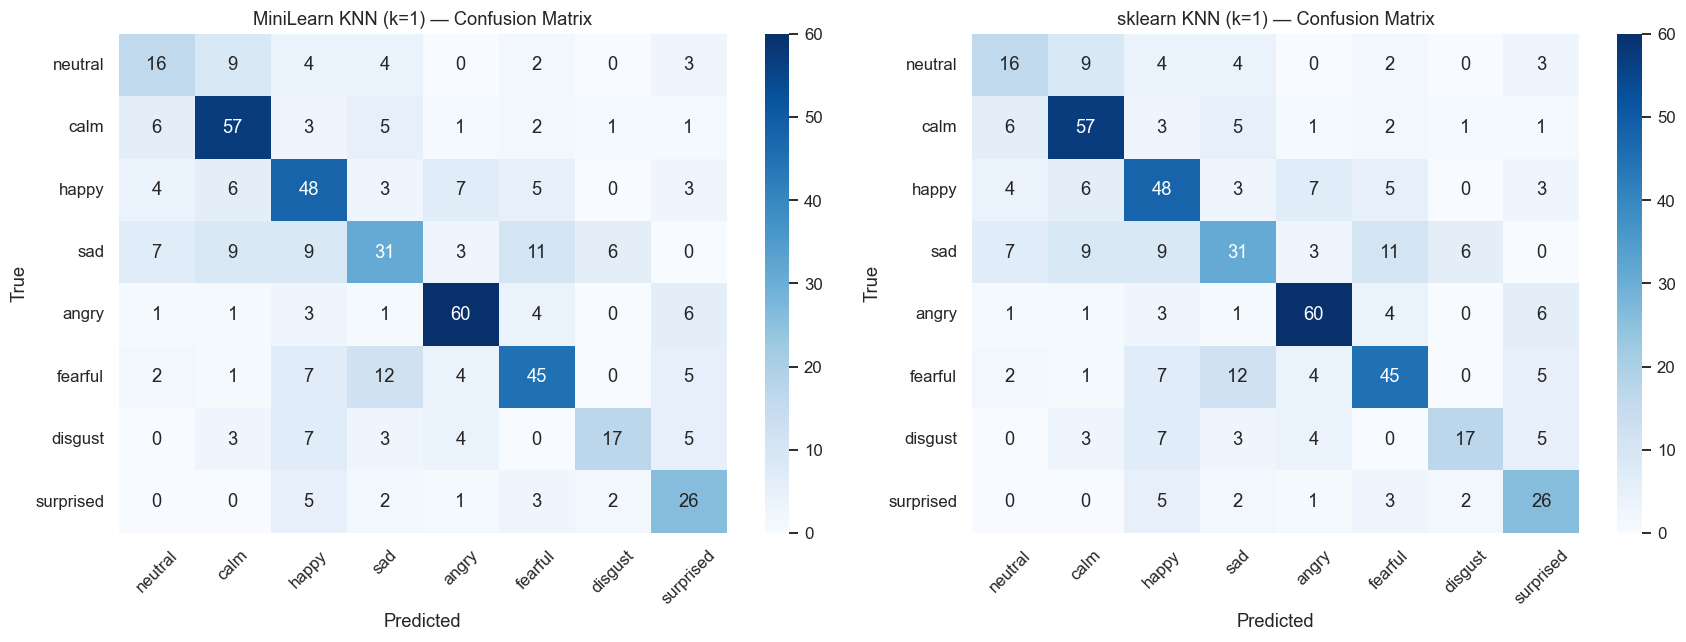

In [15]:
# ── Sweep k ─────────────────────────────────────────────────────────────────
k_values = [1, 3, 5, 7, 11]
ml_accs, sk_accs = [], []

for k in k_values:
    ml_knn = KNearestNeighbors(k=k)
    ml_knn.fit(X_train, y_train)
    ml_accs.append(accuracy(y_test, ml_knn.predict(X_test)))

    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train, y_train)
    sk_accs.append(accuracy(y_test, sk_knn.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, ml_accs, 'o-',  label='MiniLearn KNN')
ax.plot(k_values, sk_accs, 's--', label='sklearn KNN')
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN: Accuracy vs k')
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'knn_k_sweep.png'), bbox_inches='tight')
plt.show()

# ── Final evaluation at best k ───────────────────────────────────────────────
best_k = k_values[int(np.argmax(ml_accs))]
print(f'Best k (MiniLearn): {best_k}')

ml_knn_best = KNearestNeighbors(k=best_k)
ml_knn_best.fit(X_train, y_train)
y_pred_ml_knn = ml_knn_best.predict(X_test)

sk_knn_best = KNeighborsClassifier(n_neighbors=best_k)
sk_knn_best.fit(X_train, y_train)
y_pred_sk_knn = sk_knn_best.predict(X_test)

print('\n=== MiniLearn KNN (k={}) ==='.format(best_k))
print(f'Accuracy : {accuracy(y_test, y_pred_ml_knn):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_ml_knn, average="macro"):.4f}')
classification_report(y_test, y_pred_ml_knn, class_names=emotion_labels)

print('\n=== sklearn KNN (k={}) ==='.format(best_k))
print(f'Accuracy : {accuracy(y_test, y_pred_sk_knn):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_sk_knn, average="macro"):.4f}')
classification_report(y_test, y_pred_sk_knn, class_names=emotion_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion(confusion_matrix(y_test, y_pred_ml_knn),
               f'MiniLearn KNN (k={best_k}) — Confusion Matrix', axes[0], emotion_labels)
plot_confusion(confusion_matrix(y_test, y_pred_sk_knn),
               f'sklearn KNN (k={best_k}) — Confusion Matrix',   axes[1], emotion_labels)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_knn.png'), bbox_inches='tight')
plt.show()

## 5. Summary Comparison Table

                              Accuracy  Macro-F1  Precision  Recall
Model                                                              
MiniLearn LogisticRegression    0.6452    0.6402     0.6374  0.6468
sklearn  LogisticRegression     0.6734    0.6693     0.6656  0.6747
MiniLearn GaussianNaiveBayes    0.3750    0.3490     0.3785  0.3706
sklearn  GaussianNB             0.3750    0.3490     0.3785  0.3706
MiniLearn KNN (k=1)             0.6048    0.5841     0.5916  0.5868
sklearn  KNN (k=1)              0.6048    0.5841     0.5916  0.5868


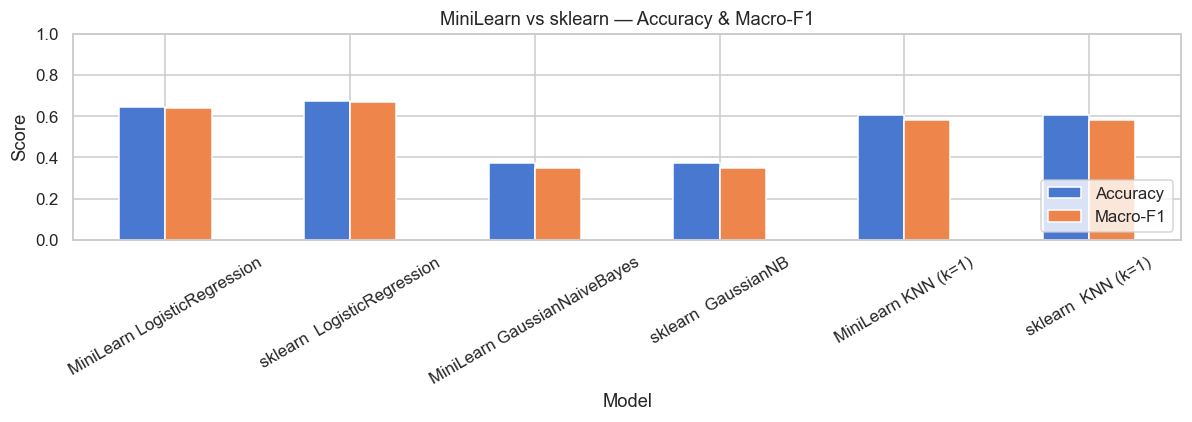

In [16]:
rows = []
for label, y_pred in [
    ('MiniLearn LogisticRegression', y_pred_ml_lr),
    ('sklearn  LogisticRegression',  y_pred_sk_lr),
    ('MiniLearn GaussianNaiveBayes', y_pred_ml_nb),
    ('sklearn  GaussianNB',          y_pred_sk_nb),
    (f'MiniLearn KNN (k={best_k})',  y_pred_ml_knn),
    (f'sklearn  KNN (k={best_k})',   y_pred_sk_knn),
]:
    rows.append({
        'Model':     label,
        'Accuracy':  round(accuracy(y_test, y_pred), 4),
        'Macro-F1':  round(f1_score(y_test, y_pred, average='macro'),    4),
        'Precision': round(precision(y_test, y_pred, average='macro'),   4),
        'Recall':    round(recall(y_test, y_pred,    average='macro'),   4),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())

# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
summary[['Accuracy', 'Macro-F1']].plot(kind='bar', ax=ax, rot=30)
ax.set_title('MiniLearn vs sklearn — Accuracy & Macro-F1')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'classifier_comparison.png'), bbox_inches='tight')
plt.show()

## 6. Discussion

*Address:*
- *Which classifier performs best?  Why might that be given the nature of audio features?*
- *Which emotions are most frequently confused?  Look at the confusion matrices.*
- *How closely does your MiniLearn implementation match sklearn?  Any numerical differences?*